In [116]:
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt

In [117]:
path = "/Users/sarah-rosemay/Documents/EEG_data/EEG_DATA_05_4_2026/Halo_4ch_ica.set"

raw = mne.io.read_raw_eeglab(path, preload=True)

print(raw)
print(raw.ch_names)
print(raw.info["sfreq"])

Reading /Users/sarah-rosemay/Documents/EEG_data/EEG_DATA_05_4_2026/Halo_4ch_ica.fdt
Reading 0 ... 66974  =      0.000 ...   267.896 secs...
<RawEEGLAB | Halo_4ch_ica.fdt, 4 x 66975 (267.9 s), ~2.1 MB, data loaded>
['O1', 'O2', 'Fp2', 'Fp1']
250.0


/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_22820/2929315400.py:3: RuntimeWarning: Estimated head radius (11.2 cm) is above the 99th percentile for adult head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(path, preload=True)


In [118]:
#run ICA https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html
# Components from EEGLab=3

ica = ICA( n_components=3,random_state=97, max_iter="auto")

ica.fit(raw)

print(ica)

Fitting ICA to data using 4 channels (please be patient, this may take a while)
Selecting by number: 3 components
Fitting ICA took 0.1s.
<ICA | raw data decomposition, method: fastica (fit in 23 iterations on 66975 samples), 3 ICA components (4 PCA components available), channel types: eeg, no sources marked for exclusion>


/var/folders/33/qg_ry0_n2kb_gsw589xg9z_w0000gn/T/ipykernel_22820/2821554602.py:6: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


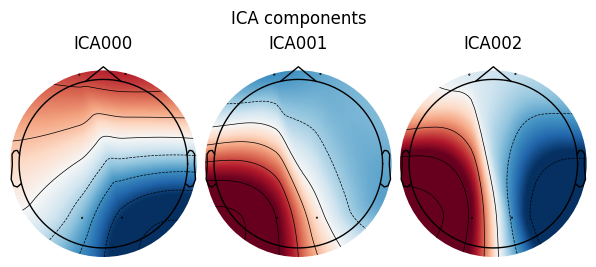

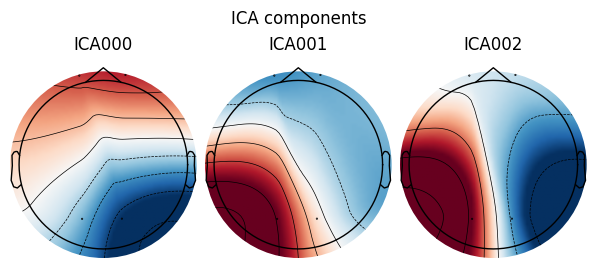

In [119]:
ica.plot_components()

In [120]:
sources = ica.get_sources(raw)
ic_data = sources.get_data()

fs = raw.info["sfreq"]
times = np.arange(ic_data.shape[1]) / fs

print(ic_data.shape)

(3, 66975)


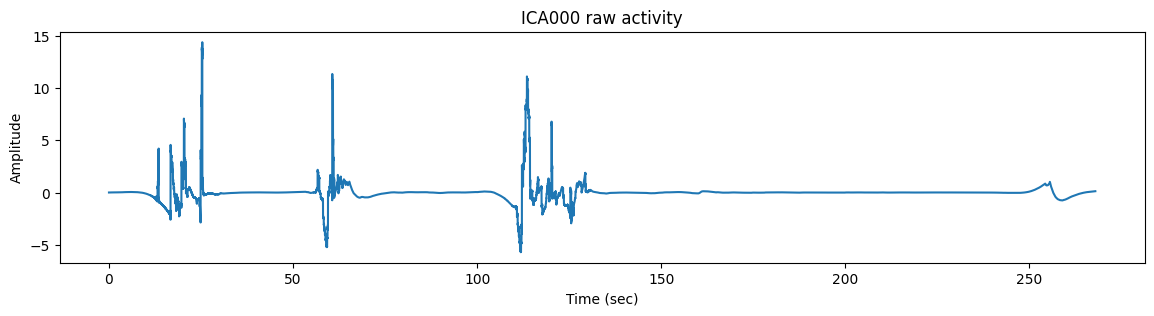

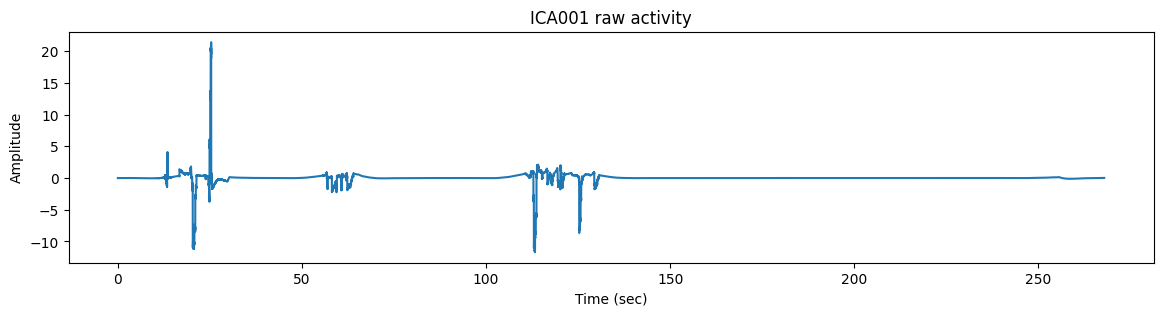

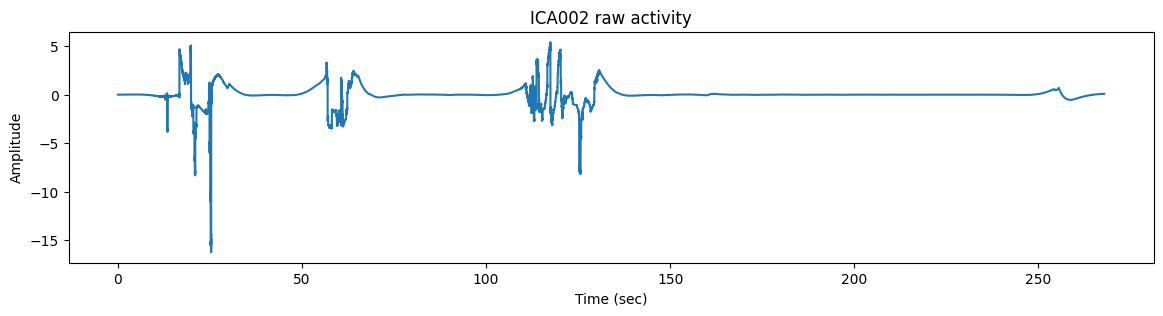

In [121]:
for i in range(ic_data.shape[0]):
    plt.figure(figsize=(14, 3))
    plt.plot(times, ic_data[i])
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(f"ICA{i:03d} raw activity")
    plt.show()

In [122]:
ic_breath = []

for i in range(ic_data.shape[0]):

    info_ic = mne.create_info(
        ch_names=[f"IC{i:03d}"],
        sfreq=fs,
        ch_types=["eeg"]
    )

    ic_raw = mne.io.RawArray(
        ic_data[i][np.newaxis, :],
        info_ic
    )

    ic_raw.filter(
        l_freq=0.1,
        h_freq=0.4,
        picks=[f"IC{i:03d}"]
    )

    ic_breath.append(ic_raw.get_data()[0])

ic_breath = np.array(ic_breath)

print(ic_breath.shape)

Creating RawArray with float64 data, n_channels=1, n_times=66975
    Range : 0 ... 66974 =      0.000 ...   267.896 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 0.4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 0.40 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.40 Hz)
- Filter length: 8251 samples (33.004 s)

Creating RawArray with float64 data, n_channels=1, n_times=66975
    Range : 0 ... 66974 =      0.000 ...   267.896 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 0.4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal ba

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


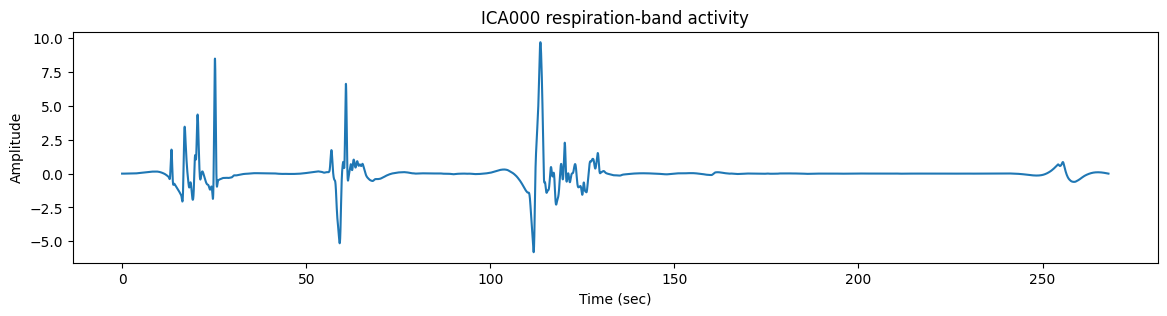

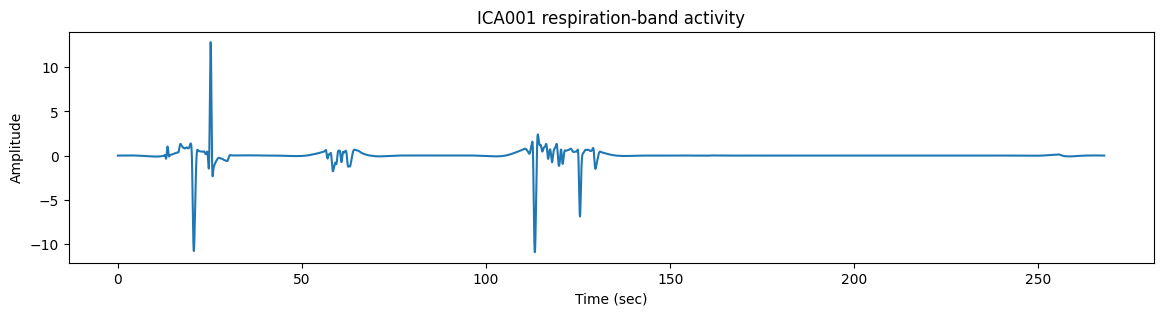

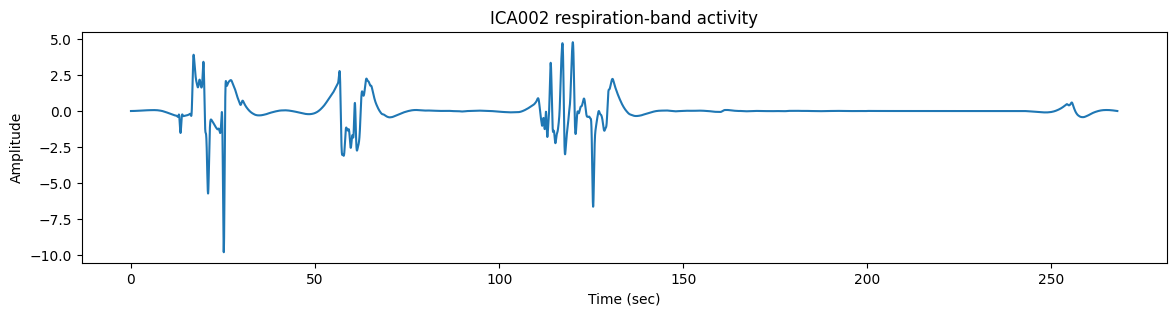

In [123]:
for i in range(ic_breath.shape[0]):

    plt.figure(figsize=(14, 3))

    plt.plot(times, ic_breath[i])

    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")

    plt.title(f"ICA{i:03d} respiration-band activity")

    plt.show()

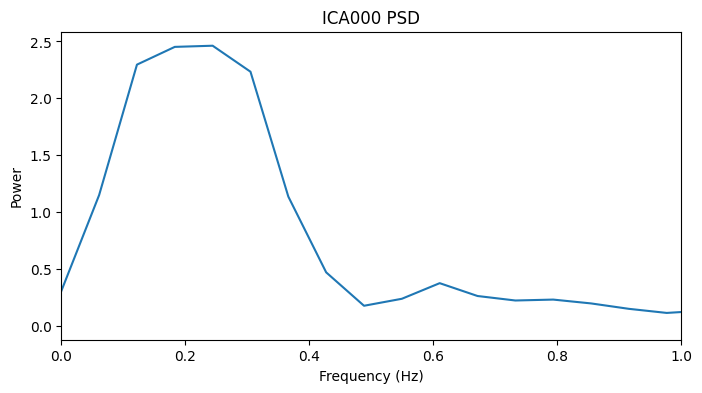

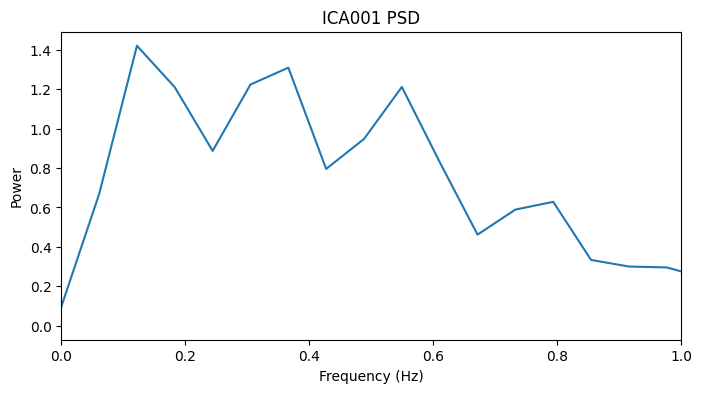

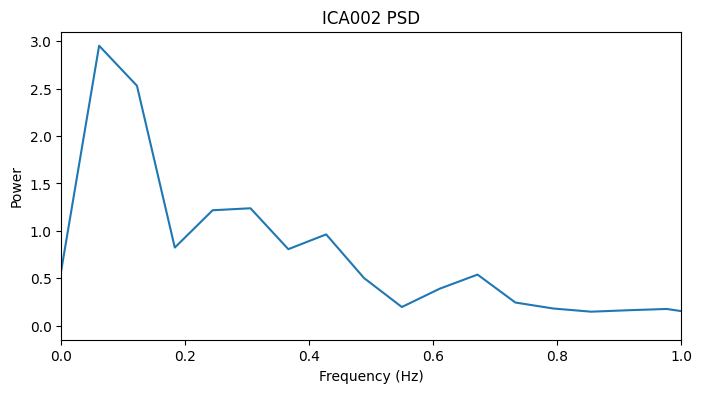

In [124]:
from scipy.signal import welch

for i in range(ic_breath.shape[0]):

    freqs, psd = welch(
        ic_breath[i],
        fs=fs,
        nperseg=4096
    )

    plt.figure(figsize=(8,4))

    plt.plot(freqs, psd)

    plt.xlim(0, 1)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")

    plt.title(f"ICA{i:03d} PSD")

    plt.show()

In [125]:
import sqlite3
import pandas as pd
import numpy as np
import mne
from mne.preprocessing import ICA
from io import BytesIO
import matplotlib.pyplot as plt

In [126]:
db_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db"

conn = sqlite3.connect(db_path)

table_name = "data_87d03f26-0f33-4e1d-a259-2181ccc29071"

df = pd.read_sql_query(
    f"SELECT * FROM '{table_name}'",
    conn
)

print(df.shape)

(3772, 3)


In [127]:
fp1_list = []
fp2_list = []
o1_list = []
o2_list = []

for b in df["data"]:
    chunk = np.load(BytesIO(b), allow_pickle=True)

    o1_list.append(chunk[0])
    o2_list.append(chunk[1])
    fp2_list.append(chunk[2])
    fp1_list.append(chunk[3])

fp1 = np.concatenate(fp1_list)
fp2 = np.concatenate(fp2_list)
o1 = np.concatenate(o1_list)
o2 = np.concatenate(o2_list)

print(fp1.shape, fp2.shape, o1.shape, o2.shape)

(133600,) (133600,) (133600,) (133600,)


In [128]:
eeg_data = np.vstack([fp1, fp2, o1, o2]) / 1e6

info = mne.create_info(
    ch_names=["Fp1", "Fp2", "O1", "O2"],
    sfreq=250,
    ch_types="eeg"
)

raw = mne.io.RawArray(eeg_data, info)

montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, on_missing="ignore")

print(raw)
print(raw.ch_names)

Creating RawArray with float64 data, n_channels=4, n_times=133600
    Range : 0 ... 133599 =      0.000 ...   534.396 secs
Ready.
<RawArray | 4 x 133600 (534.4 s), ~4.1 MB, data loaded>
['Fp1', 'Fp2', 'O1', 'O2']


In [129]:
raw_clean = raw.copy()

raw_clean.filter(l_freq=0.1, h_freq=45)

raw_clean.set_eeg_reference("average")

print(raw_clean)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 8251 samples (33.004 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
<RawArray | 4 x 133600 (534.4 s), ~4.1 MB, data loaded>


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished


In [130]:
ica = ICA(
    n_components=3,
    random_state=97,
    max_iter="auto"
)

ica.fit(raw_clean)

print(ica)

Fitting ICA to data using 4 channels (please be patient, this may take a while)
Selecting by number: 3 components
Fitting ICA took 0.1s.
<ICA | raw data decomposition, method: fastica (fit in 30 iterations on 133600 samples), 3 ICA components (4 PCA components available), channel types: eeg, no sources marked for exclusion>


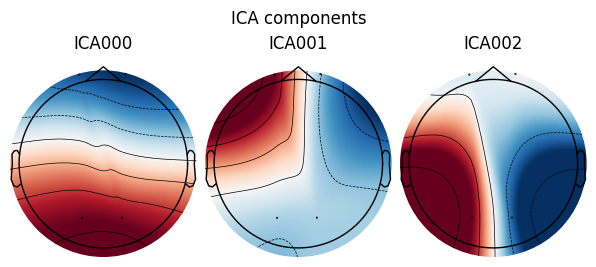

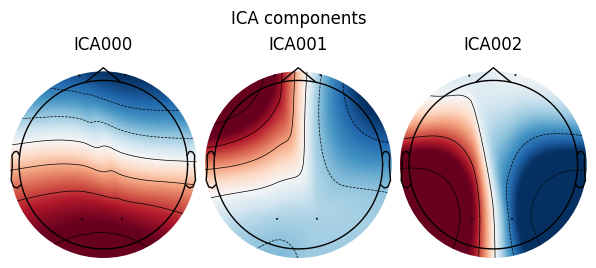

In [131]:
ica.plot_components(inst=raw_clean)

In [132]:
sources = ica.get_sources(raw_clean)

ic_data = sources.get_data()

fs = raw_clean.info["sfreq"]
times = np.arange(ic_data.shape[1]) / fs

print(ic_data.shape)

(3, 133600)


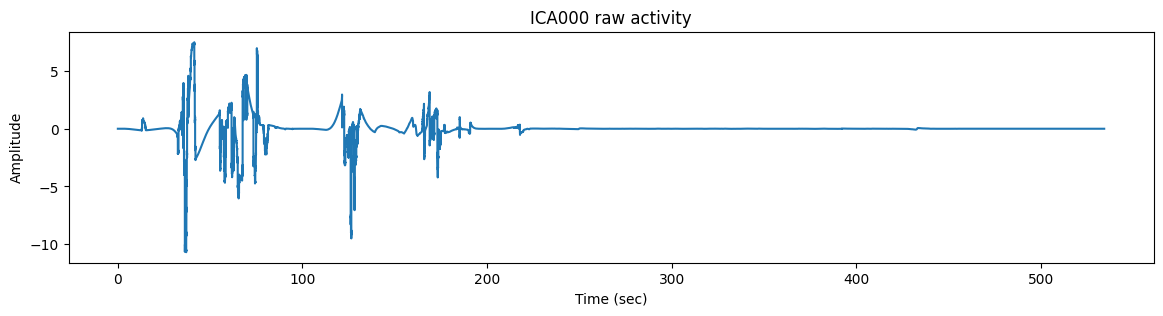

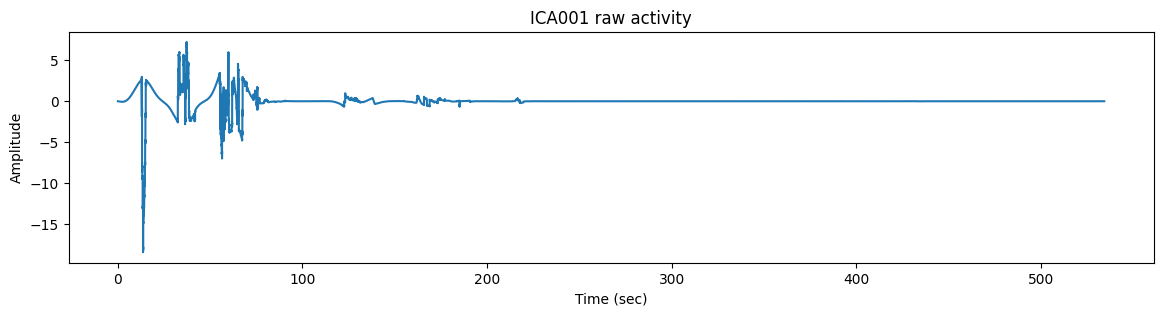

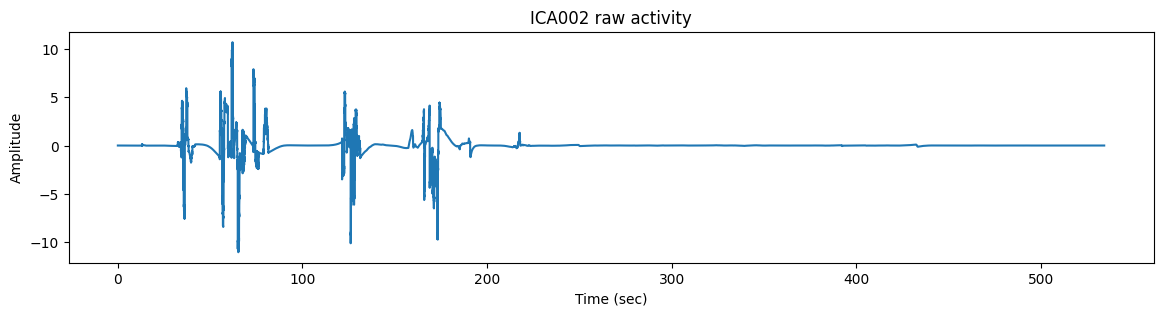

In [133]:
for i in range(ic_data.shape[0]):
    plt.figure(figsize=(14, 3))
    plt.plot(times, ic_data[i])
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(f"ICA{i:03d} raw activity")
    plt.show()

In [134]:
ic_breath = []

for i in range(ic_data.shape[0]):

    info_ic = mne.create_info(
        ch_names=[f"IC{i:03d}"],
        sfreq=fs,
        ch_types=["eeg"]
    )

    ic_raw = mne.io.RawArray(
        ic_data[i][np.newaxis, :],
        info_ic
    )

    ic_raw.filter(
        l_freq=0.1,
        h_freq=0.4,
        picks=[f"IC{i:03d}"]
    )

    ic_breath.append(ic_raw.get_data()[0])

ic_breath = np.array(ic_breath)

print(ic_breath.shape)

Creating RawArray with float64 data, n_channels=1, n_times=133600
    Range : 0 ... 133599 =      0.000 ...   534.396 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 0.4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 0.40 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.40 Hz)
- Filter length: 8251 samples (33.004 s)

Creating RawArray with float64 data, n_channels=1, n_times=133600
    Range : 0 ... 133599 =      0.000 ...   534.396 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 0.4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causa

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


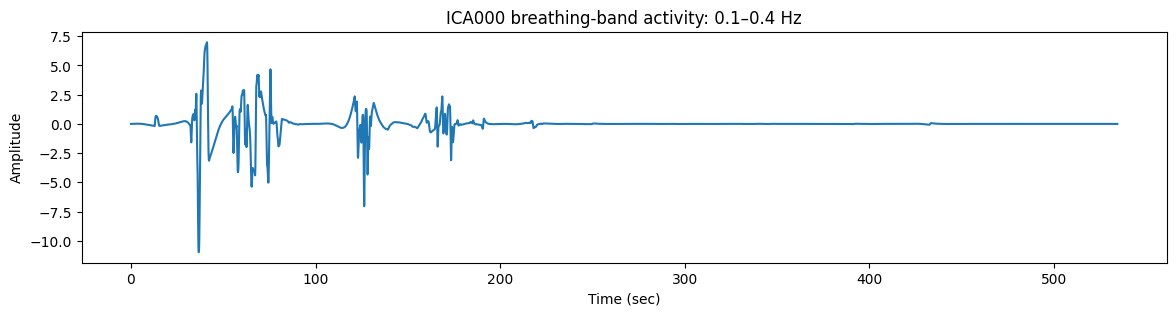

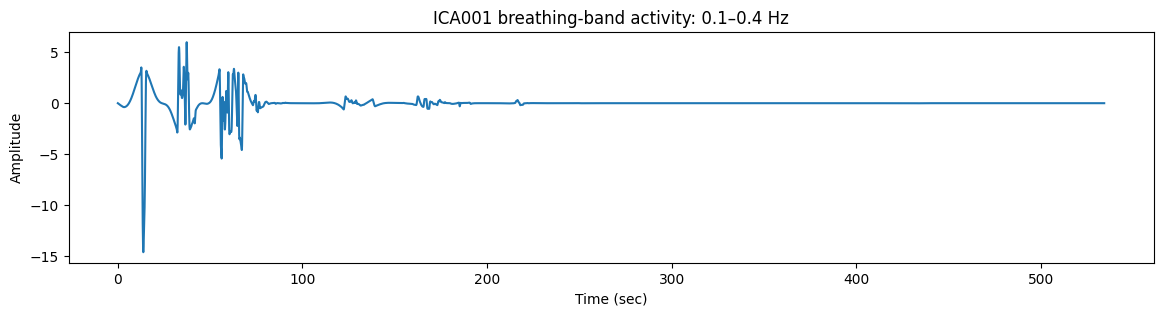

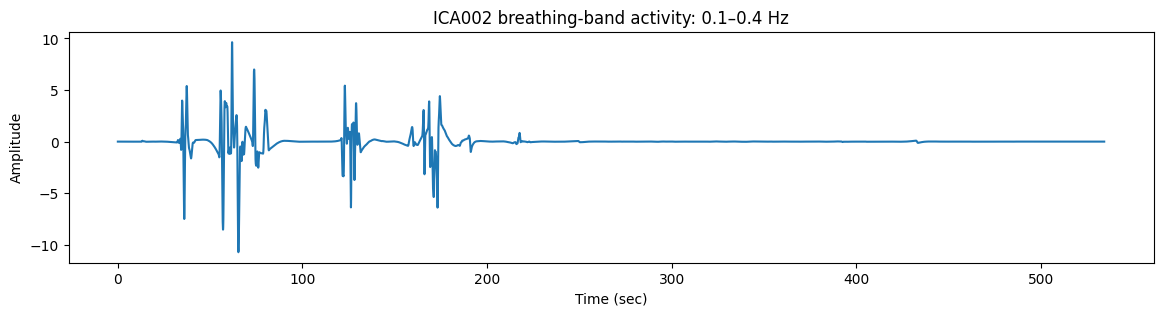

In [135]:
for i in range(ic_breath.shape[0]):
    plt.figure(figsize=(14, 3))
    plt.plot(times, ic_breath[i])
    plt.xlabel("Time (sec)")
    plt.ylabel("Amplitude")
    plt.title(f"ICA{i:03d} breathing-band activity: 0.1–0.4 Hz")
    plt.show()

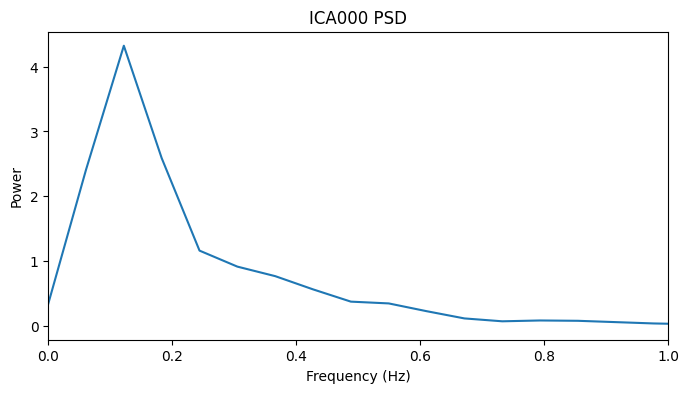

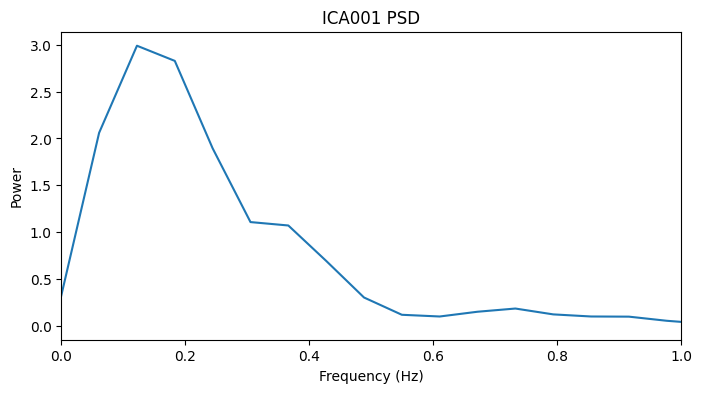

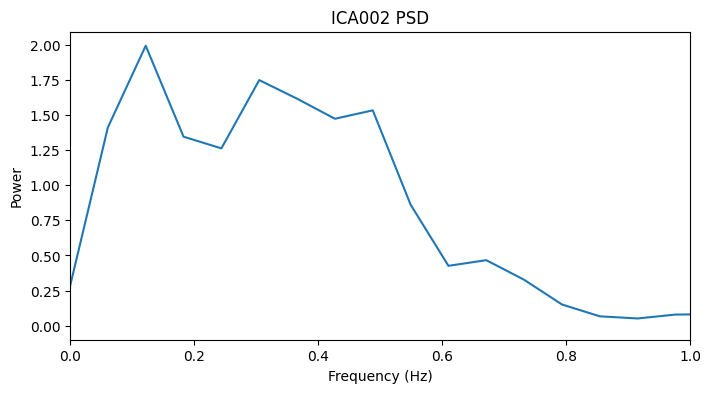

In [136]:
from scipy.signal import welch

for i in range(ic_breath.shape[0]):

    freqs, psd = welch(
        ic_breath[i],
        fs=fs,
        nperseg=4096
    )

    plt.figure(figsize=(8,4))

    plt.plot(freqs, psd)

    plt.xlim(0, 1)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")

    plt.title(f"ICA{i:03d} PSD")

    plt.show()